In [128]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix)
from sklearn.metrics import ConfusionMatrixDisplay

import torch
from torch import nn
from torch.utils.data import TensorDataset
from torch.utils.data import Subset
from torch.optim import RMSprop

from pytorch_lightning import Trainer, seed_everything
from pytorch_lightning.loggers import CSVLogger
from pytorch_lightning.callbacks import RichProgressBar

from torchinfo import summary

from ISLP.torch import SimpleDataModule, SimpleModule, ErrorTracker, rec_num_workers



In [3]:
# For Reproducibility 
seed_everything(0, workers=True)
torch.use_deterministic_algorithms(True, warn_only=True)

Seed set to 0


In [4]:
df = pd.read_csv("LondonCars2014.csv")

## Performing EDA on the dataset

In [5]:
df.head()

,Make,Model,Year,Mileage,Price,Body Style,Ex Color,In Color,Engine,Transmission,Doors
0,Toyota,Avalon XLE,2014,4725,28995,Sedan,Gray,Black,6 Cyl,Automatic,4
1,Ford,Escape SE,2014,17201,24994,SUV,Silver,Black,4 Cyl,Automatic,4
2,Hyundai,Santa Fe Sport,2014,6279,25998,SUV,Silver,Gray,4 Cyl,Automatic,4
3,Ford,Escape SE,2014,16262,26684,SUV,Black,Black,4 Cyl,Automatic,4
4,Jeep,Grand Cherokee Limited Edition,2014,35572,33440,SUV,Black,Black,6 Cyl,Automatic,4


In [6]:
df.describe()

,Year,Mileage,Price,Doors
count,9080.000000,9080.000000,9080.000000,9080.000000
mean,2010.498018,41875.531057,24410.926652,3.821035
std,2.773451,33146.564303,16300.355339,0.561866
min,1990.000000,1.000000,1490.000000,2.000000
25%,2010.000000,20112.250000,15987.750000,4.000000
50%,2011.000000,33532.000000,21500.000000,4.000000
75%,2012.000000,52564.500000,28998.000000,4.000000
max,2015.000000,279950.000000,499898.000000,4.000000


In [7]:
print("Nulls:\n", df.isnull().sum())

Nulls:
 Make            0
Model           0
Year            0
Mileage         0
Price           0
Body Style      0
Ex Color        0
In Color        0
Engine          0
Transmission    0
Doors           0
dtype: int64


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9080 entries, 0 to 9079
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Make          9080 non-null   object
 1   Model         9080 non-null   object
 2   Year          9080 non-null   int64 
 3   Mileage       9080 non-null   int64 
 4   Price         9080 non-null   int64 
 5   Body Style    9080 non-null   object
 6   Ex Color      9080 non-null   object
 7   In Color      9080 non-null   object
 8   Engine        9080 non-null   object
 9   Transmission  9080 non-null   object
 10  Doors         9080 non-null   int64 
dtypes: int64(4), object(7)
memory usage: 780.4+ KB


In [9]:
df = df.astype({'Make':'category', 'Model':'category', 'Year':'int32', 
                'Mileage':'int32', 'Price':'int64', 'Body Style':'category', 
                'Ex Color':'category' , 'In Color':'category', 
                'Engine':'category', 'Transmission':'category', 'Doors':'int32'})

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9080 entries, 0 to 9079
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Make          9080 non-null   category
 1   Model         9080 non-null   category
 2   Year          9080 non-null   int32   
 3   Mileage       9080 non-null   int32   
 4   Price         9080 non-null   int64   
 5   Body Style    9080 non-null   category
 6   Ex Color      9080 non-null   category
 7   In Color      9080 non-null   category
 8   Engine        9080 non-null   category
 9   Transmission  9080 non-null   category
 10  Doors         9080 non-null   int32   
dtypes: category(7), int32(3), int64(1)
memory usage: 292.3 KB


In [11]:
df[["Price", "Mileage"]].corr(numeric_only=True)

,Price,Mileage
Price,1.000000,-0.405068
Mileage,-0.405068,1.000000


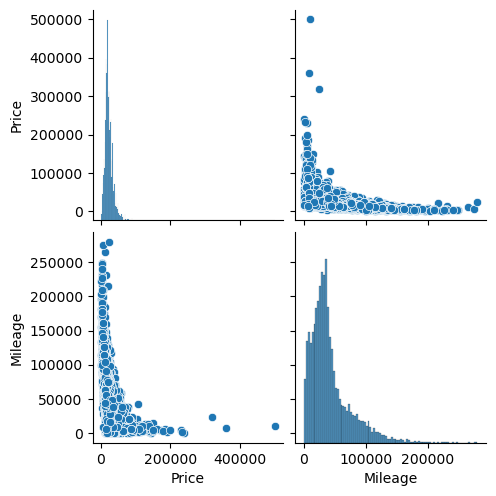

In [12]:
sns.pairplot(df[["Price", "Mileage"]])

## Data Preprocessing

In [13]:
# Fetching categorical columns
cat_cols = df.select_dtypes(include='category').columns.tolist()
print("Categorical columns requiring encoding:\n", cat_cols)

print("Unique value counts:")
for col in cat_cols:
    print(f"  {col}: {df[col].nunique()} unique values")

Categorical columns requiring encoding:
 ['Make', 'Model', 'Body Style', 'Ex Color', 'In Color', 'Engine', 'Transmission']
Unique value counts:
  Make: 49 unique values
  Model: 1060 unique values
  Body Style: 10 unique values
  Ex Color: 15 unique values
  In Color: 9 unique values
  Engine: 10 unique values
  Transmission: 2 unique values


In [14]:
df_encoded = df.copy() # making copy of original dataset

In [15]:
df_encoded.head() # dataset before encoding categorical variables

,Make,Model,Year,Mileage,Price,Body Style,Ex Color,In Color,Engine,Transmission,Doors
0,Toyota,Avalon XLE,2014,4725,28995,Sedan,Gray,Black,6 Cyl,Automatic,4
1,Ford,Escape SE,2014,17201,24994,SUV,Silver,Black,4 Cyl,Automatic,4
2,Hyundai,Santa Fe Sport,2014,6279,25998,SUV,Silver,Gray,4 Cyl,Automatic,4
3,Ford,Escape SE,2014,16262,26684,SUV,Black,Black,4 Cyl,Automatic,4
4,Jeep,Grand Cherokee Limited Edition,2014,35572,33440,SUV,Black,Black,6 Cyl,Automatic,4


In [16]:
df_encoded.shape #shape of dataset before encoding

(9080, 11)

In [17]:
# Encoding categorical variables
# Label Encoding  for 'Model' as it has 1060 unique values, OHE would explode features
# One-Hot Encoding for all other categorical columns

# Label Encoding
le = LabelEncoder()
df_encoded['Model'] = le.fit_transform(df_encoded['Model'].astype(str))

# One Hot Encoding for all other categorical columns
ohe_cols = ['Make', 'Body Style', 'Ex Color', 'In Color', 'Engine', 'Transmission']
df_encoded = pd.get_dummies(df_encoded, columns=ohe_cols, drop_first=True, dtype=int)


In [18]:
df_encoded.head() # dataset after encoding categorical variables

,Model,Year,Mileage,Price,Doors,Make_Aston,Make_Audi,Make_BMW,Make_Bentley,Make_Buick,...,Engine_12 Cyl,Engine_3 Cyl,Engine_4 Cyl,Engine_5 Cyl,Engine_6 Cyl,Engine_8 Cyl,Engine_Electric,Engine_Hybrid,Engine_Rotary,Transmission_Manual
0,134,2014,4725,28995,4,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,353,2014,17201,24994,4,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
2,840,2014,6279,25998,4,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3,353,2014,16262,26684,4,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,485,2014,35572,33440,4,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [19]:
df_encoded.shape # shape of dataset after encoding

(9080, 94)

In [20]:
# Train-Test Split

# Separating features (X) and target (y)
X = df_encoded.drop(columns=['Price'])
y = df_encoded['Price'].values.reshape(-1, 1)

# 70/30 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42
)

print(f"Training set : {X_train.shape}")
print(f"Testing set  : {X_test.shape}")

Training set : (6356, 93)
Testing set  : (2724, 93)


In [21]:
# Normalising Numeric Data

# Normalising features
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)

# Normalising label
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train).ravel()
y_test_scaled  = scaler_y.transform(y_test).ravel()

In [22]:
print(f"X_train shape : {X_train_scaled.shape}")
print(f"X_test  shape : {X_test_scaled.shape}")
print(f"y_train shape : {y_train_scaled.shape}")
print(f"y_test  shape : {y_test_scaled.shape}")
print(f"Split ratio   : {len(X_train)/len(X)*100}% / {len(X_test)/len(X)*100}%")

X_train shape : (6356, 93)
X_test  shape : (2724, 93)
y_train shape : (6356,)
y_test  shape : (2724,)
Split ratio   : 70.0% / 30.0%


In [23]:
X_train_scaled

array([[ 0.0313026 ,  0.544564  , -0.60053513, ..., -0.10085458,
        -0.01254418, -0.18255934],
       [-1.47604005, -0.1826655 ,  1.64074762, ..., -0.10085458,
        -0.01254418, -0.18255934],
       [ 1.1956176 , -2.00073924,  1.34120047, ..., -0.10085458,
        -0.01254418, -0.18255934],
       ...,
       [-1.47604005,  0.18094925, -0.49472676, ..., -0.10085458,
        -0.01254418, -0.18255934],
       [ 1.24509274,  0.18094925,  1.14311383, ..., -0.10085458,
        -0.01254418, -0.18255934],
       [ 1.34734137,  0.18094925, -0.46429165, ..., -0.10085458,
        -0.01254418, -0.18255934]])

In [24]:
# Converting numpy arrays to tensors, as PyTorch needs float32 tensors

X_train_t = torch.tensor(X_train_scaled.astype(np.float32))
X_test_t  = torch.tensor(X_test_scaled.astype(np.float32))
y_train_t = torch.tensor(y_train_scaled.astype(np.float32))
y_test_t  = torch.tensor(y_test_scaled.astype(np.float32))

cars_train = TensorDataset(X_train_t, y_train_t)
cars_test  = TensorDataset(X_test_t,  y_test_t)

print(f"Train tensors: X {X_train_t.shape}, y {y_train_t.shape}")
print(f"Test  tensors: X {X_test_t.shape},  y {y_test_t.shape}")

Train tensors: X torch.Size([6356, 93]), y torch.Size([6356])
Test  tensors: X torch.Size([2724, 93]),  y torch.Size([2724])


## Implementing Regression Neural Network

In [25]:
max_num_workers = rec_num_workers()

### Configuring simple model without validation and regularisation

In [26]:
cars_dm = SimpleDataModule(
    cars_train,
    cars_test,
    validation=None,
    batch_size=100,
    num_workers=max_num_workers)


In [27]:
# printing shape of one mini-batch
for X_, y_ in cars_dm.train_dataloader():
    print(f"One mini-batch -> X: {X_.shape}, y: {y_.shape}")
    break

One mini-batch -> X: torch.Size([100, 93]), y: torch.Size([100])


In [28]:
# Defining NN Model Architecture

class CarsRegModel(nn.Module):
    def __init__(self, input_size):
        super(CarsRegModel, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, 50),
            nn.ReLU())
        self.layer2 = nn.Sequential(
            nn.Linear(50, 20),
            nn.ReLU())
        self._forward = nn.Sequential(
            self.layer1,
            self.layer2,
            nn.Linear(20, 1))

    def forward(self, x):
        return torch.flatten(self._forward(x))

In [29]:
# Instantiate and inspect

input_size = X_train_scaled.shape[1] # 93
cars_model = CarsRegModel(input_size)

In [30]:
summary(cars_model,
        input_size=(100, input_size),
        col_names=['input_size', 'output_size', 'num_params'])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
CarsRegModel                             [100, 93]                 [100]                     --
├─Sequential: 1-1                        [100, 93]                 [100, 1]                  --
│    └─Sequential: 2-1                   [100, 93]                 [100, 50]                 --
│    │    └─Flatten: 3-1                 [100, 93]                 [100, 93]                 --
│    │    └─Linear: 3-2                  [100, 93]                 [100, 50]                 4,700
│    │    └─ReLU: 3-3                    [100, 50]                 [100, 50]                 --
│    └─Sequential: 2-2                   [100, 50]                 [100, 20]                 --
│    │    └─Linear: 3-4                  [100, 50]                 [100, 20]                 1,020
│    │    └─ReLU: 3-5                    [100, 20]                 [100, 20]                 --
│    └─Linear: 2-3           

In [31]:
# Wrap our model in SimpleModule.regression 
cars_module = SimpleModule.regression(cars_model)

cars_logger = CSVLogger('logs', name='cars_simple')

In [32]:
# Defining Trainer
cars_trainer = Trainer(
    deterministic=True,
    max_epochs=30,
    logger=cars_logger,
    enable_progress_bar=False,
    enable_model_summary=False,  
    callbacks=[ErrorTracker()])

# Fitting model
cars_trainer.fit(cars_module, datamodule=cars_dm)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/opt/anaconda3/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/anaconda3/lib/python3.13/site-packages/pytorch_lightning/utilities/data.py:106: Total length of `DataLoader` across ranks is zero. Please make sure this was your intention.
`Trainer.fit` stopped: `max_epochs=30` reached.


In [33]:
# Evaluating Model

# MSE score
test_results = cars_trainer.test(cars_module, datamodule=cars_dm)
test_mse = test_results[0]['test_loss']

# Calculating R² on test set
cars_model.eval()
with torch.no_grad():
    y_pred = cars_model(X_test_t).numpy()

test_r2 = r2_score(y_test_t.numpy(), y_pred)

print(f"Regression NN: Test set performance:")
print(f"MSE : {test_mse:.4f}")
print(f"R²  : {test_r2:.4f}")

/opt/anaconda3/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │    0.1136838048696518     │
└───────────────────────────┴───────────────────────────┘

Regression NN: Test set performance:
MSE : 0.1137
R²  : 0.8638


In [161]:
# Ploting train-loss and epochs plot

def plot_loss_curve(log_path, title):
    """Plot training loss curve from a CSVLogger metrics.csv file."""
    m = pd.read_csv(log_path)
    train = m[['epoch', 'train_loss']].dropna().groupby('epoch').mean()
    
    plt.figure(figsize=(7, 3.5))
    plt.plot(train.index, train['train_loss'], marker='o', linewidth=1.5)
    plt.xlabel('Epoch')
    plt.ylabel('Training loss')
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

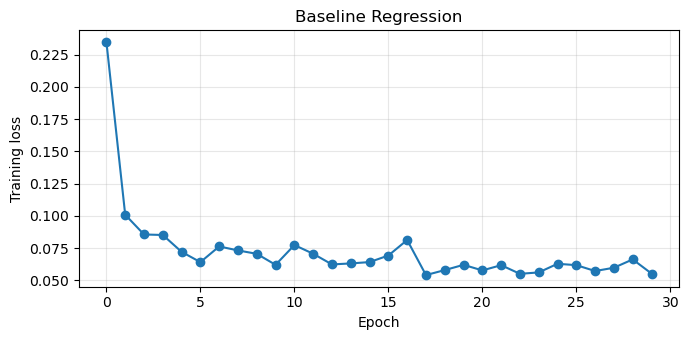

In [162]:
plot_loss_curve('logs/cars_simple/version_0/metrics.csv', 'Baseline Regression')

### Configuring model with validation and regularisation

In [34]:
# Improved Regression Model

class CarsRegModelImproved(nn.Module):
    def __init__(self, input_size, dropout):
        super(CarsRegModelImproved, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, 50),
            nn.ReLU(),
            nn.Dropout(dropout))
        self.layer2 = nn.Sequential(
            nn.Linear(50, 20),
            nn.ReLU(),
            nn.Dropout(dropout))
        self._forward = nn.Sequential(
            self.layer1,
            self.layer2,
            nn.Linear(20, 1))

    def forward(self, x):
        return torch.flatten(self._forward(x))

In [35]:
#  Using Grid Search to find best (dropout, weight_decay) combination with k-fold validation

dropouts = [0.2, 0.3, 0.4]
lambdas = [0.001, 0.01, 0.1, 1, 10, 50, 100, 500, 1000]
K = 5

kf = KFold(n_splits=K, shuffle=True, random_state=42)
n_train = len(cars_train)

cv_results = []


print("Executing Training")
for dp in dropouts:
    for lam in lambdas:
        fold_mses = []

        for fold_idx, (tr_idx, val_idx) in enumerate(kf.split(np.arange(n_train))):
            seed_everything(0, workers=True) 

            train_subset = Subset(cars_train, tr_idx)
            val_subset   = Subset(cars_train, val_idx)

            dm = SimpleDataModule(
                train_subset, cars_test,
                validation=val_subset,
                batch_size=100,
                num_workers=rec_num_workers(),
            )

            model = CarsRegModelImproved(input_size=93, dropout=dp)
            optimiser = RMSprop(model.parameters(), lr=0.001, weight_decay=lam)
            
            module = SimpleModule.regression(model, optimizer=optimiser)

            trainer = Trainer(
                deterministic=True, 
                max_epochs=30, 
                logger=CSVLogger('logs_kfold', name=f'dp{dp}_l{lam}_f{fold_idx}'),
                callbacks=[ErrorTracker()],
                enable_progress_bar=False, 
                enable_model_summary=False)
            
            trainer.fit(module, datamodule=dm)
            val = trainer.validate(module, datamodule=dm, verbose=False)

            fold_mses.append(val[0]['valid_loss'])

        cv_results.append({
            'dropout':       dp,
            'lambda':        lam,
            'mean_val_mse':  np.mean(fold_mses),
        })
        print(f"dropout={dp}, λ={lam} > mean val MSE = {np.mean(fold_mses):.4f}")



Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Executing Training


/opt/anaconda3/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
`Trainer.fit` stopped: `max_epochs=30` reached.
Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
`Trainer.fit` stopped: `max_epochs=30` reached.
Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litl

dropout=0.2, λ=0.001 > mean val MSE = 0.1297


`Trainer.fit` stopped: `max_epochs=30` reached.
Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
`Trainer.fit` stopped: `max_epochs=30` reached.
Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try

...

dropout=0.4, λ=100 > mean val MSE = 1.0000


`Trainer.fit` stopped: `max_epochs=30` reached.
Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
`Trainer.fit` stopped: `max_epochs=30` reached.
Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try

dropout=0.4, λ=500 > mean val MSE = 1.0000


`Trainer.fit` stopped: `max_epochs=30` reached.
Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
`Trainer.fit` stopped: `max_epochs=30` reached.
Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try

dropout=0.4, λ=1000 > mean val MSE = 1.0000


In [38]:
cv_df = pd.DataFrame(cv_results).sort_values('mean_val_mse').reset_index(drop=True)
print("All combinations sorted:")
print(cv_df.to_string(index=False))

best = cv_df.iloc[0]
print(f"Best: dropout={best['dropout']}, lambda={best['lambda']}")

All combinations sorted:
 dropout   lambda  mean_val_mse
     0.2    0.001      0.129719
     0.3    0.001      0.141039
     0.2    0.010      0.147900
     0.4    0.001      0.155180
     0.3    0.010      0.157147
     0.4    0.010      0.170480
     0.2    0.100      0.202042
     0.3    0.100      0.208345
     0.4    0.100      0.218639
     0.3   50.000      0.999996
     0.2   50.000      0.999996
     0.4   50.000      0.999996
     0.2  100.000      1.000000
     0.4  100.000      1.000000
     0.3  100.000      1.000000
     0.4   10.000      1.000002
     0.2   10.000      1.000002
     0.3   10.000      1.000002
     0.4  500.000      1.000011
     0.2  500.000      1.000011
     0.3  500.000      1.000011
     0.4 1000.000      1.000012
     0.3 1000.000      1.000012
     0.2 1000.000      1.000012
     0.4    1.000      1.000077
     0.2    1.000      1.000077
     0.3    1.000      1.000077
Best: dropout=0.2, lambda=0.001


In [39]:
#  Final improved model with full dataset

best_dropout = 0.2
best_lambda  = 0.001

seed_everything(0, workers=True)

# preparing data module with validation none, as validation is already done
cars_dm_improved = SimpleDataModule(
    cars_train, cars_test,
    validation=None,                      
    batch_size=100,
    num_workers=rec_num_workers(),
)

cars_model_improved = CarsRegModelImproved(input_size=93, dropout=best_dropout)

# custom optimiser with best lambda for regularisation
optimiser = RMSprop(
    cars_model_improved.parameters(),
    lr=0.001,
    weight_decay=best_lambda,
)

cars_module_improved  = SimpleModule.regression(cars_model_improved, optimizer=optimiser)


Seed set to 0


In [40]:
# Initializing trainer

cars_trainer_improved = Trainer(
    deterministic=True, 
    max_epochs=30,
    logger=CSVLogger('logs_final', name='cars_improved'),
    callbacks=[ErrorTracker()],
    enable_progress_bar=False,
    enable_model_summary=False)


cars_trainer_improved.fit(cars_module_improved, datamodule=cars_dm_improved)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/opt/anaconda3/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/anaconda3/lib/python3.13/site-packages/pytorch_lightning/utilities/data.py:106: Total length of `DataLoader` across ranks is zero. Please make sure this was your intention.
`Trainer.fit` stopped: `max_epochs=30` reached.


In [41]:
# Evaluate on test set

results_improved = cars_trainer_improved.test(cars_module_improved, datamodule=cars_dm_improved)
test_mse_improved = results_improved[0]['test_loss']

cars_model_improved.eval()
with torch.no_grad():
    y_pred_improved = cars_model_improved(X_test_t).numpy()
    
test_r2_improved = r2_score(y_test_t.numpy(), y_pred_improved)

print(f"Test set performance of improved model")
print(f"  MSE : {test_mse_improved:.4f}")
print(f"  R²  : {test_r2_improved:.4f}")

/opt/anaconda3/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │    0.10722649097442627    │
└───────────────────────────┴───────────────────────────┘

Test set performance of improved model
  MSE : 0.1072
  R²  : 0.8716


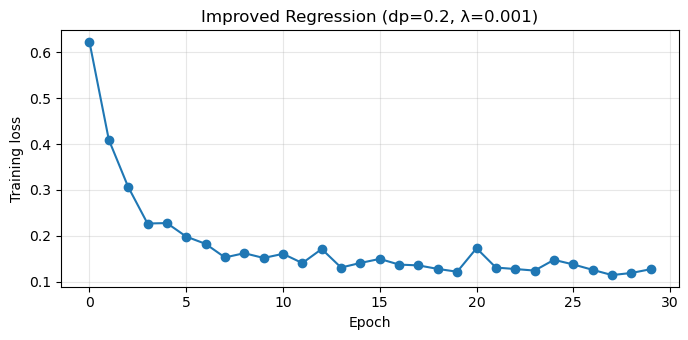

In [163]:
plot_loss_curve('logs_final/cars_improved/version_0/metrics.csv', 'Improved Regression (dp=0.2, λ=0.001)')

## Implementing Classification Neural Network

### Data preprocessing for classification

In [83]:
# copying row data in another variable
df_clf = df.copy()

# creating bins using pandas cut() method
df_clf['Price_label'] = pd.cut(
    df_clf['Price'],
    bins=[-np.inf, 15986, 48500, np.inf],     # three bins are here (-∞-15986, 15986-48500, 48500-∞)
    labels=['low', 'medium', 'high']
)

df_clf.tail()

,Make,Model,Year,Mileage,Price,Body Style,Ex Color,In Color,Engine,Transmission,Doors,Price_label
9075,Chevrolet,Malibu LT,2010,40340,12998,Sedan,Silver,Black,4 Cyl,Automatic,4,low
9076,Ford,Edge SEL,2009,43169,18495,SUV,Blue,Gray,6 Cyl,Automatic,4,medium
9077,Dodge,Avenger SXT,2012,6761,14944,Sedan,Silver,Black,4 Cyl,Automatic,4,low
9078,Mercedes-Benz,ML 350,2011,38215,35900,SUV,Silver,Black,6 Cyl,Automatic,4,medium
9079,Nissan,Altima SL,2010,44065,13499,Sedan,Gray,Black,4 Cyl,Automatic,4,low


In [84]:
# exploring classes balance
print(df_clf['Price_label'].value_counts().sort_index())

Price_label
low       2268
medium    6397
high       415
Name: count, dtype: int64


In [85]:
# encoding dataset 

# encoding target label in three classes
price_order = {'low': 0, 'medium': 1, 'high': 2}
y_clf = df_clf['Price_label'].map(price_order)

# extracting features
df_X = df_clf.drop(columns=['Price_label', 'Price'])

# encodig model as label encoder and rest as one-hot encoding
df_X['Model'] = LabelEncoder().fit_transform(df_X['Model'].astype(str))
df_X = pd.get_dummies(
    df_X,
    columns=['Make', 'Body Style', 'Ex Color', 'In Color', 'Engine', 'Transmission'],
    drop_first=True, dtype=int
)

In [86]:
# Stratified 70/30 split to preserves class proportions

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    df_X, y_clf, test_size=0.30, random_state=42, stratify=y_clf
)


In [87]:
# Scaling features

scaler_X_c = StandardScaler()
X_train_c_scaled = scaler_X_c.fit_transform(X_train_c)
X_test_c_scaled  = scaler_X_c.transform(X_test_c)

In [97]:
# converting to tensor

X_train_c_t = torch.tensor(X_train_c_scaled.astype(np.float32))
X_test_c_t  = torch.tensor(X_test_c_scaled.astype(np.float32))
y_train_c_t = torch.tensor(y_train_c.values.astype(np.int64))
y_test_c_t  = torch.tensor(y_test_c.values.astype(np.int64)) # y must be int64 for cross-entropy loss

cars_clf_train = TensorDataset(X_train_c_t, y_train_c_t)
cars_clf_test  = TensorDataset(X_test_c_t,  y_test_c_t)

### Implementing shallow neural network

In [103]:
# Shallow NN with 1 hidden layer containing 150 neurons

class ShallowNN(nn.Module):
    def __init__(self, input_size, num_classes, activation):
        super(ShallowNN, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, 150),
            activation)
        self._forward = nn.Sequential(
            self.layer1, 
            nn.Linear(150, num_classes))

    def forward(self, x):
        return self._forward(x)


# Activation function map 
activations = {
    'ReLU':      nn.ReLU(),
    'LeakyReLU': nn.LeakyReLU(),
    'Sigmoid':   nn.Sigmoid(),
    'Tanh':      nn.Tanh(),
    'Swish':     nn.SiLU(),
}

In [104]:
# Tunning hyperparameters activation function and L2 lambda with grid search k-fold cv

shallow_activations = ['ReLU', 'LeakyReLU', 'Sigmoid', 'Tanh', 'Swish']
shallow_lambdas     = [0.001, 0.01, 0.1]
K = 5

kf = KFold(n_splits=K, shuffle=True, random_state=42)
n_train_c = len(cars_clf_train)

shallow_cv_results = []
print("Running shallow NN cross-validation...")

for act_name in shallow_activations:
    for lam in shallow_lambdas:
        fold_accs = []

        for fold_idx, (tr_idx, val_idx) in enumerate(kf.split(np.arange(n_train_c))):
            seed_everything(0, workers=True)
            
            train_subset = Subset(cars_clf_train, tr_idx)
            val_subset   = Subset(cars_clf_train, val_idx)

            dm = SimpleDataModule(
                train_subset, 
                cars_clf_test,
                validation=val_subset, 
                batch_size=100,
                num_workers=rec_num_workers(),
            )

            model = ShallowNN(input_size=93, num_classes=3, activation=activations[act_name])
            optimiser = RMSprop(model.parameters(), lr=0.001, weight_decay=lam)

            module = SimpleModule.classification(model, num_classes=3, optimizer=optimiser)

            trainer = Trainer(
                deterministic=True, 
                max_epochs=30, 
                logger=CSVLogger('logs_shallow_cv', name=f'{act_name}_l{lam}_f{fold_idx}'),
                callbacks=[ErrorTracker()],
                enable_progress_bar=False, 
                enable_model_summary=False)
            
            trainer.fit(module, datamodule=dm)

            val = trainer.validate(module, datamodule=dm, verbose=False)
            fold_accs.append(val[0]['valid_accuracy'])

        shallow_cv_results.append({
            'activation': act_name,
            'lambda':     lam,
            'mean_val_acc': np.mean(fold_accs),
        })
        print(f"  {act_name:<10s}  λ={lam:<6g}  mean val acc = {np.mean(fold_accs):.4f}")
            


Seed set to 0


Running shallow NN cross-validation...


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/opt/anaconda3/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
`Trainer.fit` stopped: `max_epochs=30` reached.
Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogge

  ReLU        λ=0.001   mean val acc = 0.8981


`Trainer.fit` stopped: `max_epochs=30` reached.
Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
`Trainer.fit` stopped: `max_epochs=30` reached.
Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try

...

  Swish       λ=0.001   mean val acc = 0.8952


`Trainer.fit` stopped: `max_epochs=30` reached.
Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
`Trainer.fit` stopped: `max_epochs=30` reached.
Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try

  Swish       λ=0.01    mean val acc = 0.8874


`Trainer.fit` stopped: `max_epochs=30` reached.
Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
`Trainer.fit` stopped: `max_epochs=30` reached.
Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try

  Swish       λ=0.1     mean val acc = 0.8469


In [106]:

shallow_cv_df = pd.DataFrame(shallow_cv_results).sort_values('mean_val_acc', ascending=False).reset_index(drop=True)
print("Shallow NN CV results, sorted by val accuracy")
print(shallow_cv_df.to_string(index=False))

best_shallow = shallow_cv_df.iloc[0]
print(f"\nBest: activation={best_shallow['activation']}, lambda={best_shallow['lambda']}")


Shallow NN CV results, sorted by val accuracy
activation  lambda  mean_val_acc
 LeakyReLU   0.001      0.898209
      ReLU   0.001      0.898051
      Tanh   0.001      0.897106
     Swish   0.001      0.895218
 LeakyReLU   0.010      0.891442
      ReLU   0.010      0.890812
     Swish   0.010      0.887351
   Sigmoid   0.001      0.886092
      Tanh   0.010      0.883102
   Sigmoid   0.010      0.870517
      Tanh   0.100      0.853052
 LeakyReLU   0.100      0.852110
      ReLU   0.100      0.851481
     Swish   0.100      0.846918
   Sigmoid   0.100      0.726559

Best: activation=LeakyReLU, lambda=0.001


In [107]:
# Training shallow NN on the full dataset with the tunned hyperparameters

seed_everything(0, workers=True)

shallow_dm = SimpleDataModule(
    cars_clf_train, 
    cars_clf_test,
    validation=None,
    batch_size=100,
    num_workers=rec_num_workers(),
)

shallow_model = ShallowNN(input_size=93, num_classes=3, activation=nn.LeakyReLU())
shallow_optimiser = RMSprop(shallow_model.parameters(), lr=0.001, weight_decay=0.001)

shallow_module = SimpleModule.classification(shallow_model, num_classes=3, optimizer=shallow_optimiser)



Seed set to 0


In [108]:
shallow_trainer = Trainer(
    deterministic=True, 
    max_epochs=30, 
    logger=CSVLogger('logs_shallow_final', name='shallow'),
    callbacks=[ErrorTracker()],
    enable_progress_bar=False, 
    enable_model_summary=False)

shallow_trainer.fit(shallow_module, datamodule=shallow_dm)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/opt/anaconda3/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/anaconda3/lib/python3.13/site-packages/pytorch_lightning/utilities/data.py:106: Total length of `DataLoader` across ranks is zero. Please make sure this was your intention.
`Trainer.fit` stopped: `max_epochs=30` reached.


In [111]:
# Get predictions

shallow_model.eval()
with torch.no_grad():
    logits = shallow_model(X_test_c_t)
    y_pred_shallow = logits.argmax(dim=1).numpy()

y_true = y_test_c_t.numpy()

print("Shallow NN, Test set performance")
print(f"  Accuracy: {accuracy_score(y_true, y_pred_shallow):.4f}")
print(f"  Precision: {precision_score(y_true, y_pred_shallow, average='macro', zero_division=0):.4f}")
print(f"  Recall: {recall_score(y_true, y_pred_shallow, average='macro', zero_division=0):.4f}")
print(f"  F1: {f1_score(y_true, y_pred_shallow, average='macro', zero_division=0):.4f}")

print("\nPer-class breakdown:")
print(classification_report(y_true, y_pred_shallow,
                             target_names=['low', 'medium', 'high'],
                             zero_division=0))

Shallow NN, Test set performance
  Accuracy: 0.9023
  Precision: 0.8736
  Recall: 0.8223
  F1: 0.8455

Per-class breakdown:
              precision    recall  f1-score   support

         low       0.85      0.83      0.84       680
      medium       0.92      0.94      0.93      1919
        high       0.84      0.70      0.76       125

    accuracy                           0.90      2724
   macro avg       0.87      0.82      0.85      2724
weighted avg       0.90      0.90      0.90      2724



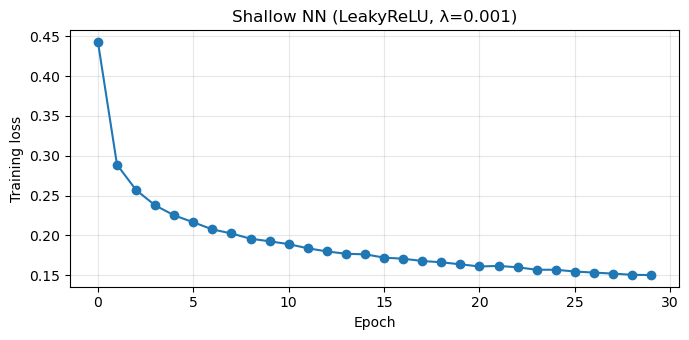

In [164]:
plot_loss_curve('logs_shallow_final/shallow/version_0/metrics.csv', 'Shallow NN (LeakyReLU, λ=0.001)')

### Implementing Deep Neural Network

In [112]:
#  Implementing deep NN with 4 hidden layers 

class DeepNN(nn.Module):
    def __init__(self, input_size, num_classes, activation, dropout):
        super(DeepNN, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, 162),
            activation,
            nn.Dropout(dropout))
        self.layer2 = nn.Sequential(
            nn.Linear(162, 81),
            activation,
            nn.Dropout(dropout))
        self.layer3 = nn.Sequential(
            nn.Linear(81, 27),
            activation,
            nn.Dropout(dropout))
        self.layer4 = nn.Sequential(
            nn.Linear(27, 9),
            activation,
            nn.Dropout(dropout))
        self._forward = nn.Sequential(
            self.layer1, self.layer2, self.layer3, self.layer4,
            nn.Linear(9, num_classes))

    def forward(self, x):
        return self._forward(x)

In [113]:
# architecture check
deep_check = DeepNN(input_size=93, num_classes=3, activation=nn.SiLU(), dropout=0.4)
summary(deep_check, input_size=(100, 93), col_names=['input_size', 'output_size', 'num_params'])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
DeepNN                                   [100, 93]                 [100, 3]                  --
├─Sequential: 1-1                        [100, 93]                 [100, 3]                  --
│    └─Sequential: 2-1                   [100, 93]                 [100, 162]                --
│    │    └─Flatten: 3-1                 [100, 93]                 [100, 93]                 --
│    │    └─Linear: 3-2                  [100, 93]                 [100, 162]                15,228
│    └─Sequential: 2-8                   --                        --                        (recursive)
│    │    └─SiLU: 3-3                    [100, 162]                [100, 162]                --
│    └─Sequential: 2-3                   --                        --                        (recursive)
│    │    └─Dropout: 3-4                 [100, 162]                [100, 162]                --
│    └─Sequen

In [115]:
# Tunning hyperparameters: activation function and dropout rate with grid search k-fold cv

deep_activations = ['ReLU', 'LeakyReLU', 'Sigmoid', 'Tanh', 'Swish']
deep_dropouts    = [0.2, 0.3, 0.4, 0.5]
K = 5

kf = KFold(n_splits=K, shuffle=True, random_state=42)
n_train_c = len(cars_clf_train)

deep_cv_results = []
print("Running deep NN cross-validation...")

for act_name in deep_activations:
    for dp in deep_dropouts:
        fold_accs = []

        for fold_idx, (tr_idx, val_idx) in enumerate(kf.split(np.arange(n_train_c))):
            seed_everything(0, workers=True)
            train_subset = Subset(cars_clf_train, tr_idx)
            val_subset   = Subset(cars_clf_train, val_idx)

            dm = SimpleDataModule(
                train_subset, 
                cars_clf_test,
                validation=val_subset, 
                batch_size=100,
                num_workers=rec_num_workers(),
            )

            model = DeepNN(input_size=93, num_classes=3, activation=activations[act_name], dropout=dp)
            optimiser = RMSprop(model.parameters(), lr=0.001)
            
            module = SimpleModule.classification(model, num_classes=3, optimizer=optimiser)

            trainer = Trainer(
                deterministic=True, 
                max_epochs=30, 
                logger=CSVLogger('logs_deep_cv', name=f'{act_name}_dp{dp}_f{fold_idx}'),
                callbacks=[ErrorTracker()],
                enable_progress_bar=False, 
                enable_model_summary=False,
            )
            
            trainer.fit(module, datamodule=dm)
            
            val = trainer.validate(module, datamodule=dm, verbose=False)
            fold_accs.append(val[0]['valid_accuracy'])

        deep_cv_results.append({
            'activation':  act_name,
            'dropout':     dp,
            'mean_val_acc': np.mean(fold_accs),
        })
        print(f"  {act_name:<10s}  dp={dp}  mean val acc = {np.mean(fold_accs):.4f}")




Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Running deep NN cross-validation...


/opt/anaconda3/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
`Trainer.fit` stopped: `max_epochs=30` reached.
Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
`Trainer.fit` stopped: `max_epochs=30` reached.
Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litl

  ReLU        dp=0.2  mean val acc = 0.8936


`Trainer.fit` stopped: `max_epochs=30` reached.
Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
`Trainer.fit` stopped: `max_epochs=30` reached.
Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try

...

  Swish       dp=0.3  mean val acc = 0.8949


`Trainer.fit` stopped: `max_epochs=30` reached.
Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
`Trainer.fit` stopped: `max_epochs=30` reached.
Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try

  Swish       dp=0.4  mean val acc = 0.8927


`Trainer.fit` stopped: `max_epochs=30` reached.
Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
`Trainer.fit` stopped: `max_epochs=30` reached.
Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try

  Swish       dp=0.5  mean val acc = 0.8899


In [116]:

deep_cv_df = pd.DataFrame(deep_cv_results).sort_values('mean_val_acc', ascending=False).reset_index(drop=True)
print("Deep NN CV results (sorted by val accuracy)")
print(deep_cv_df.to_string(index=False))

best_deep = deep_cv_df.iloc[0]
print(f"\nBest: activation={best_deep['activation']}, dropout={best_deep['dropout']}")


Deep NN CV results (sorted by val accuracy)
activation  dropout  mean_val_acc
      ReLU      0.3      0.896163
     Swish      0.2      0.895690
 LeakyReLU      0.3      0.895533
     Swish      0.3      0.894904
 LeakyReLU      0.2      0.894432
      ReLU      0.2      0.893645
     Swish      0.4      0.892702
 LeakyReLU      0.4      0.891443
      Tanh      0.2      0.891285
      ReLU      0.4      0.890657
     Swish      0.5      0.889870
      Tanh      0.3      0.886723
      Tanh      0.4      0.886722
      Tanh      0.5      0.884836
 LeakyReLU      0.5      0.873508
      ReLU      0.5      0.866900
   Sigmoid      0.4      0.863595
   Sigmoid      0.2      0.863438
   Sigmoid      0.3      0.862808
   Sigmoid      0.5      0.859504

Best: activation=ReLU, dropout=0.3


In [117]:
# Training deep NN on the full dataset with the tunned hyperparameters

seed_everything(0, workers=True)

deep_dm = SimpleDataModule(
    cars_clf_train, 
    cars_clf_test,
    validation=None,
    batch_size=100,
    num_workers=rec_num_workers())

deep_model = DeepNN(input_size=93, num_classes=3, activation=nn.ReLU(), dropout=0.3)
deep_optimiser = RMSprop(deep_model.parameters(), lr=0.001)

deep_module = SimpleModule.classification(deep_model, num_classes=3, optimizer=deep_optimiser)


Seed set to 0


In [118]:
deep_trainer = Trainer(
    deterministic=True, 
    max_epochs=30,
    logger=CSVLogger('logs_deep_final', name='deep'),
    callbacks=[ErrorTracker()],
    enable_progress_bar=False, 
    enable_model_summary=False)

deep_trainer.fit(deep_module, datamodule=deep_dm)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/opt/anaconda3/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/anaconda3/lib/python3.13/site-packages/pytorch_lightning/utilities/data.py:106: Total length of `DataLoader` across ranks is zero. Please make sure this was your intention.
`Trainer.fit` stopped: `max_epochs=30` reached.


In [121]:
deep_trainer.test(deep_module, datamodule=deep_dm)

/opt/anaconda3/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.9023494720458984     │
│         test_loss         │    0.2704314589500427     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.2704314589500427, 'test_accuracy': 0.9023494720458984}]

In [138]:
deep_model.eval()
with torch.no_grad():
    y_pred_deep = deep_model(X_test_c_t).argmax(dim=1).numpy()

print("Testing deep NN test set performance")
print(f"Accuracy: {accuracy_score(y_true, y_pred_deep):.4f}")
print(f"Precision: {precision_score(y_true, y_pred_deep, average='macro', zero_division=0):.4f}")
print(f"Recall: {recall_score(y_true, y_pred_deep, average='macro', zero_division=0):.4f}")
print(f"F1: {f1_score(y_true, y_pred_deep, average='macro', zero_division=0):.4f}")

print("\nPer-class breakdown:")
print(classification_report(y_true, y_pred_deep,
                             target_names=['low', 'medium', 'high'],
                             zero_division=0))

Testing deep NN test set performance
Accuracy: 0.9023
Precision: 0.8834
Recall: 0.8051
F1: 0.8393

Per-class breakdown:
              precision    recall  f1-score   support

         low       0.89      0.78      0.84       680
      medium       0.91      0.96      0.93      1919
        high       0.85      0.67      0.75       125

    accuracy                           0.90      2724
   macro avg       0.88      0.81      0.84      2724
weighted avg       0.90      0.90      0.90      2724



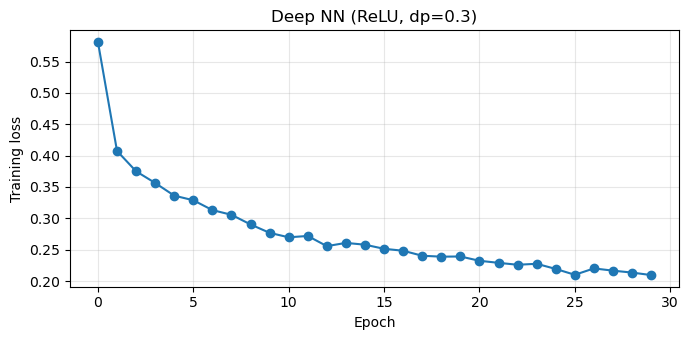

In [165]:
plot_loss_curve('logs_deep_final/deep/version_0/metrics.csv','Deep NN (ReLU, dp=0.3)')

In [133]:
y_true = y_test_c_t.numpy()

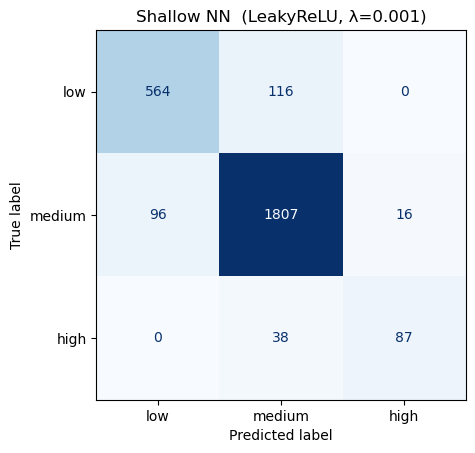

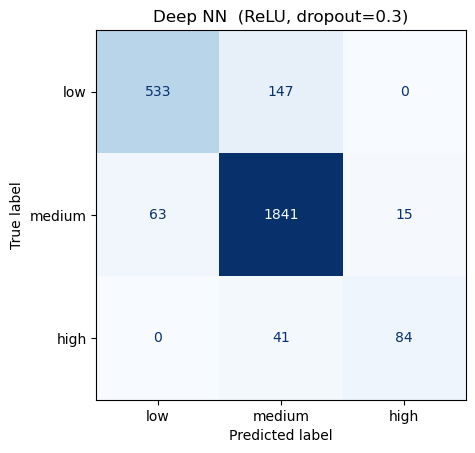

In [137]:
class_names = ['low', 'medium', 'high']

for y_pred, title in zip(
    [y_pred_shallow, y_pred_deep],
    ['Shallow NN  (LeakyReLU, λ=0.001)', 'Deep NN  (ReLU, dropout=0.3)']
):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(cmap='Blues', colorbar=False)
    plt.title(title)
    plt.show()

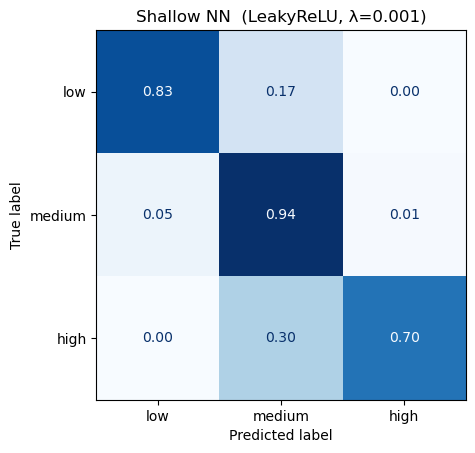

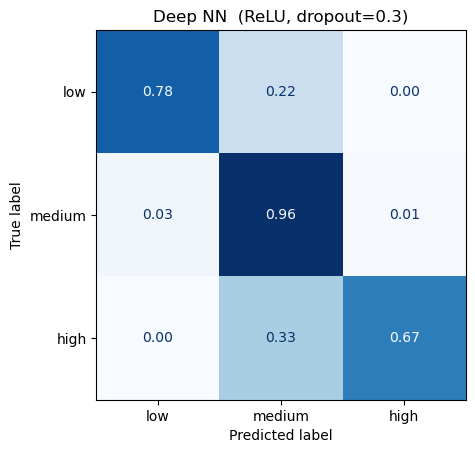

In [139]:

for y_pred, title in zip(
    [y_pred_shallow, y_pred_deep],
    ['Shallow NN  (LeakyReLU, λ=0.001)', 'Deep NN  (ReLU, dropout=0.3)']
):
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(cmap='Blues', colorbar=False, values_format='.2f')
    plt.title(title)
    plt.show()

In [151]:
# print(X_test_c_t[0])
with torch.no_grad():  # Set to evaluation mode, no gradients will be calculated
    output = deep_model(X_test_c_t)


output
print(output)

tensor([[   1.5194,    2.0440,   -9.5623],
        [  28.4761,   17.9862, -154.8303],
        [  -1.1192,    3.1882,   -5.4201],
        ...,
        [  -5.6397,    5.9268,   -4.0030],
        [  -6.1843,    6.4494,   -4.8003],
        [   6.6239,    4.8668,  -37.1770]])


In [182]:
# Apply softmax to convert logits to probabilities
probabilities = nn.functional.softmax(output, dim=1)

# Convert probabilities to percentages
percentages = probabilities * 100

print(f"{percentages[0][0].item():.4f}")
print(f"{percentages[0][1].item():.4f}")
print(f"{percentages[0][2].item():.4f}")


37.1786
62.8208
0.0006
